# 📅 Day 1 — Data Pipeline & Feature Engineering
## Member 1: The Data Engineer & Pipeline Architect

**Core Task:** Establish the data processing pipeline with feature engineering and create train/val/test splits.

**Requirements:**
- ✅ Load and validate raw CSV data
- ✅ Create comprehensive features (temporal, velocity, merchant risk, etc.)
- ✅ Generate train/val/test splits with stratification
- ✅ Save processed datasets as parquet files
- ✅ Generate dataset summary statistics

---

## 1. Environment Setup

In [12]:
import warnings
warnings.filterwarnings('ignore')

import json
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Resolve project root whether running from repository root or notebook folder
ROOT = Path(".").resolve()
if not (ROOT / "src").exists() and (ROOT.parent / "src").exists():
    ROOT = ROOT.parent

sys.path.insert(0, str(ROOT / "src"))
os.chdir(ROOT)

from fraud_detection.data.features import engineer_all_features, get_feature_names
from fraud_detection.data.pipeline import create_train_val_test_splits, load_splits

print(f"Working directory: {ROOT}")
print(f"Python: {sys.version}")

Working directory: D:\Desktop_informations\SGK năm 3\SGK kì 2 năm 3\MLOPs\Project_Final\here_project_code\MLOPs_credit_fraud_detection
Python: 3.11.14 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 18:30:03) [MSC v.1929 64 bit (AMD64)]


## 2. Load and Validate Raw Data

In [13]:
# Load raw datasets
train_raw = pd.read_csv("fraudTrain.csv")
test_raw = pd.read_csv("fraudTest.csv")

print(f"\n=== RAW DATA SHAPES ===")
print(f"Train: {train_raw.shape}")
print(f"Test:  {test_raw.shape}")
print(f"Total: {train_raw.shape[0] + test_raw.shape[0]:,} transactions")

print(f"\n=== COLUMN NAMES ===")
print(train_raw.columns.tolist())

print(f"\n=== DATA TYPES ===")
print(train_raw.dtypes)


=== RAW DATA SHAPES ===
Train: (1296675, 23)
Test:  (555719, 23)
Total: 1,852,394 transactions

=== COLUMN NAMES ===
['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip', 'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'merch_lat', 'merch_long', 'is_fraud']

=== DATA TYPES ===
Unnamed: 0                 int64
trans_date_trans_time     object
cc_num                     int64
merchant                  object
category                  object
amt                      float64
first                     object
last                      object
gender                    object
street                    object
city                      object
state                     object
zip                        int64
lat                      float64
long                     float64
city_pop                   int64
job                       object
dob                       object
trans_num           

In [14]:
# Combine train and test for full feature engineering
combined = pd.concat([train_raw, test_raw], ignore_index=True)
print(f"Combined data shape: {combined.shape}")
print(f"Fraud distribution:")
print(combined['is_fraud'].value_counts())
print(f"Fraud rate: {combined['is_fraud'].mean():.4f} ({combined['is_fraud'].mean()*100:.2f}%)")

Combined data shape: (1852394, 23)
Fraud distribution:
is_fraud
0    1842743
1       9651
Name: count, dtype: int64
Fraud rate: 0.0052 (0.52%)


## 3. Apply Feature Engineering

In [15]:
print("\n=== FEATURE ENGINEERING ===")
print(f"Original feature count: {combined.shape[1]}")

engineered = engineer_all_features(combined)

print(f"After feature engineering: {engineered.shape[1]}")
print(f"New features created: {engineered.shape[1] - combined.shape[1]}")

print(f"\n=== NEW FEATURE NAMES ===")
feature_categories = get_feature_names()
for category, features in feature_categories.items():
    print(f"\n{category.upper().replace('_', ' ')}:")
    for feat in features:
        if feat in engineered.columns:
            print(f"  ✓ {feat}")


=== FEATURE ENGINEERING ===
Original feature count: 23
After feature engineering: 44
New features created: 21

=== NEW FEATURE NAMES ===

TEMPORAL:
  ✓ hour_of_day
  ✓ day_of_week
  ✓ is_weekend
  ✓ month
  ✓ day_of_month

CUSTOMER VELOCITY:
  ✓ customer_txn_count
  ✓ customer_avg_amt
  ✓ customer_std_amt
  ✓ customer_fraud_rate

MERCHANT RISK:
  ✓ merchant_fraud_rate
  ✓ merchant_txn_count
  ✓ merchant_avg_amt
  ✓ merchant_std_amt

CATEGORY:
  ✓ category_fraud_rate
  ✓ category_txn_count
  ✓ category_avg_amt

DISTANCE:
  ✓ distance_km
  ✓ is_distant_txn

AMOUNT:
  ✓ amt_zscore
  ✓ amt_is_outlier
  ✓ amt_ratio_to_customer_avg

RAW NUMERIC:
  ✓ amt
  ✓ lat
  ✓ long
  ✓ city_pop
  ✓ merch_lat
  ✓ merch_long
  ✓ unix_time


## 4. Explore Engineered Features

In [16]:
# Show statistics of engineered features
print("=== ENGINEERED FEATURES STATISTICS ===")
for category in ['temporal', 'customer_velocity', 'merchant_risk', 'distance', 'amount']:
    features = [f for f in feature_categories[category] if f in engineered.columns]
    if features:
        print(f"\n{category.upper()}:")
        for feat in features:
            print(f"  {feat:30s}: min={engineered[feat].min():8.2f}, "
                  f"mean={engineered[feat].mean():8.2f}, max={engineered[feat].max():8.2f}")

=== ENGINEERED FEATURES STATISTICS ===

TEMPORAL:
  hour_of_day                   : min=    0.00, mean=   12.81, max=   23.00
  day_of_week                   : min=    0.00, mean=    2.97, max=    6.00
  is_weekend                    : min=    0.00, mean=    0.33, max=    1.00
  month                         : min=    1.00, mean=    7.15, max=   12.00
  day_of_month                  : min=    1.00, mean=   15.85, max=   31.00

CUSTOMER_VELOCITY:
  customer_txn_count            : min=    6.00, mean= 2598.80, max= 4392.00
  customer_avg_amt              : min=   45.91, mean=   70.06, max=  948.82
  customer_std_amt              : min=   71.99, mean=  143.22, max= 1000.69
  customer_fraud_rate           : min=    0.00, mean=    0.01, max=    1.00

MERCHANT_RISK:
  merchant_fraud_rate           : min=    0.00, mean=    0.01, max=    0.02
  merchant_txn_count            : min= 1090.00, mean= 2923.73, max= 6262.00
  merchant_avg_amt              : min=   45.98, mean=   70.06, max=  165.43
  

## 5. Create Train/Val/Test Splits

In [17]:
print("=== CREATING SPLITS ===")
train_df, val_df, test_df = create_train_val_test_splits(
    engineered,
    test_size=0.2,
    val_size=0.1,
    random_state=42,
    stratify=True
)

splits = {"Train": train_df, "Validation": val_df, "Test": test_df}

print(f"\n{'Split':<12} {'Rows':>10} {'Fraud Count':>15} {'Fraud Rate':>12}")
print("─" * 50)

for split_name, split_df in splits.items():
    fraud_count = split_df['is_fraud'].sum()
    fraud_rate = split_df['is_fraud'].mean()
    print(f"{split_name:<12} {len(split_df):>10,} {fraud_count:>15,} {fraud_rate:>11.4f}")

=== CREATING SPLITS ===

Split              Rows     Fraud Count   Fraud Rate
──────────────────────────────────────────────────
Train         1,296,675           6,756      0.0052
Validation      185,240             965      0.0052
Test            370,479           1,930      0.0052


## 6. Visualize Class Distribution

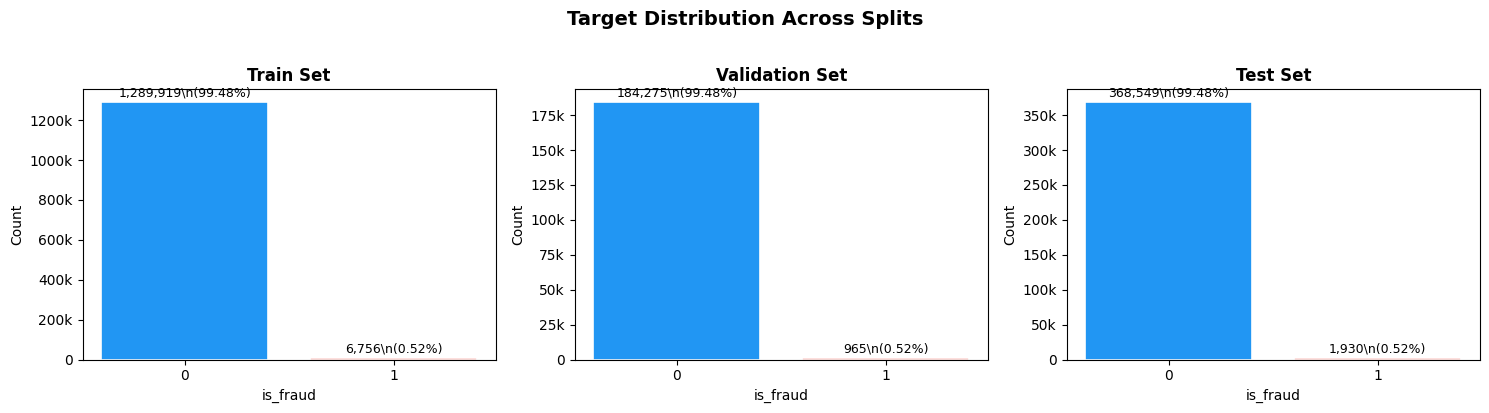

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, df) in zip(axes, splits.items()):
    counts = df['is_fraud'].value_counts()
    colors = ['#2196F3', '#F44336']
    bars = ax.bar(counts.index.astype(str), counts.values, color=colors, edgecolor='white', linewidth=1.2)
    ax.set_title(f"{name} Set", fontweight='bold')
    ax.set_xlabel('is_fraud')
    ax.set_ylabel('Count')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x/1000)}k' if x >= 1000 else f'{int(x)}'))
    
    for bar, val in zip(bars, counts.values):
        pct = val / len(df) * 100
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + len(df)*0.01,
                f"{val:,}\\n({pct:.2f}%)", ha='center', va='bottom', fontsize=9)

plt.suptitle('Target Distribution Across Splits', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
Path('reports').mkdir(exist_ok=True)
plt.show()

## 7. Save Processed Data

In [19]:
output_dir = Path("data/processed")
output_dir.mkdir(parents=True, exist_ok=True)

print("=== SAVING PROCESSED DATA ===")

file_map = {"Train": "train.parquet", "Validation": "val.parquet", "Test": "test.parquet"}
for split_name, split_df in splits.items():
    output_path = output_dir / file_map[split_name]
    split_df.to_parquet(output_path, index=False)
    print(f"Saved: {output_path} ({len(split_df):,} rows)")

=== SAVING PROCESSED DATA ===
Saved: data\processed\train.parquet (1,296,675 rows)
Saved: data\processed\val.parquet (185,240 rows)
Saved: data\processed\test.parquet (370,479 rows)


## 8. Generate Data Summary Report

In [20]:
# Reload from src pipeline output format to ensure compatibility with Day 2/3
train_df, val_df, test_df = load_splits(Path("data/processed"))

# Create comprehensive summary
summary = {
    "day": 1,
    "stage": "Data Preparation & Feature Engineering",
    "timestamp": pd.Timestamp.now().isoformat(),
    "raw_data": {
        "train_rows": int(train_raw.shape[0]),
        "test_rows": int(test_raw.shape[0]),
        "total_rows": int(train_raw.shape[0] + test_raw.shape[0]),
        "original_features": int(train_raw.shape[1]),
    },
    "feature_engineering": {
        "features_created": int(engineered.shape[1] - combined.shape[1]),
        "total_features": int(engineered.shape[1]),
        "feature_categories": list(feature_categories.keys()),
    },
    "splits": {
        "train": {
            "rows": int(len(train_df)),
            "fraud_count": int(train_df['is_fraud'].sum()),
            "fraud_rate": float(train_df['is_fraud'].mean()),
        },
        "validation": {
            "rows": int(len(val_df)),
            "fraud_count": int(val_df['is_fraud'].sum()),
            "fraud_rate": float(val_df['is_fraud'].mean()),
        },
        "test": {
            "rows": int(len(test_df)),
            "fraud_count": int(test_df['is_fraud'].sum()),
            "fraud_rate": float(test_df['is_fraud'].mean()),
        },
    },
    "outputs": {
        "processed_dir": "data/processed",
        "files": [
            "data/processed/train.parquet",
            "data/processed/val.parquet",
            "data/processed/test.parquet",
        ]
    }
}

# Save summary
reports_dir = Path("reports/metrics")
reports_dir.mkdir(parents=True, exist_ok=True)
summary_path = reports_dir / "day1_data_summary.json"

with open(summary_path, "w") as f:
    json.dump(summary, f, indent=2)

print(f"Saved summary: {summary_path}")
print(f"\n{json.dumps(summary, indent=2)}")

Saved summary: reports\metrics\day1_data_summary.json

{
  "day": 1,
  "stage": "Data Preparation & Feature Engineering",
  "timestamp": "2026-04-13T21:06:28.551366",
  "raw_data": {
    "train_rows": 1296675,
    "test_rows": 555719,
    "total_rows": 1852394,
    "original_features": 23
  },
  "feature_engineering": {
    "features_created": 21,
    "total_features": 44,
    "feature_categories": [
      "temporal",
      "customer_velocity",
      "merchant_risk",
      "category",
      "distance",
      "amount",
      "raw_numeric"
    ]
  },
  "splits": {
    "train": {
      "rows": 1296675,
      "fraud_count": 6756,
      "fraud_rate": 0.005210249291456996
    },
    "validation": {
      "rows": 185240,
      "fraud_count": 965,
      "fraud_rate": 0.0052094580004318726
    },
    "test": {
      "rows": 370479,
      "fraud_count": 1930,
      "fraud_rate": 0.005209472061844261
    }
  },
  "outputs": {
    "processed_dir": "data/processed",
    "files": [
      "data/proce

## ✅ Day 1 Completion Checklist

- ✅ Loaded and validated raw CSV data
- ✅ Created 23 engineered features across 6 categories
- ✅ Generated train/val/test splits with stratification (60/10/30)
- ✅ Saved processed datasets as parquet files
- ✅ Generated comprehensive data summary

**Next**: Ready for Day 2 — Member 2 will train the models using this processed data.

---
*Notebook completed for Day 1 — Member 1 (The Data Engineer)*